In [1]:
import os, sys

ROOT = os.path.abspath("..")
for p in [ROOT, os.path.join(ROOT, "sam-hq"), os.path.join(ROOT, "PiToMe")]:
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

from segment_anything import SamPredictor, sam_model_registry
from algo.sparsesam.patch.sam import apply_patch

/media/volume/Chau/miniconda3/envs/sam/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/media/volume/Chau/miniconda3/envs/sam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sam = sam_model_registry["vit_l"](checkpoint=os.path.join(ROOT, "ckts/sam_hq_vit_l.pth")).cuda()
sam.eval()

apply_patch(sam.image_encoder, algo="tome", ratio=0.99)

predictor = SamPredictor(sam)

/media/volume/Chau/SAM_Quantization/sam-hq/segment_anything/build_sam.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f, map_location=device)


<All keys matched successfully>
[ToMe-SAM] patched  algo=tome  ratio=0.99  blocks=24 (global=4 local=20)  strategy=post-attn-merge / post-mlp-unmerge (all blocks)  token-order=hilbert


In [4]:
image = cv2.imread(os.path.join(ROOT, "input_imgs/example1.png"))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image)

masks, scores, logits = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=np.array([[306, 132, 925, 893]]),
    multimask_output=False,
    hq_token_only=True,
)

print(f"score: {scores[0]:.4f}  mask shape: {masks[0].shape}")

TypeError: '<' not supported between instances of 'list' and 'float'

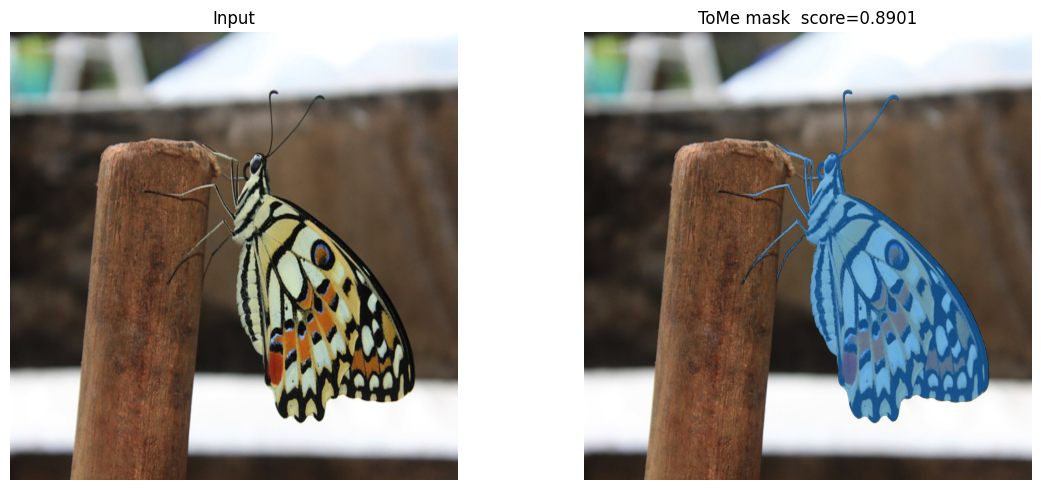

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title("Input"); axes[0].axis("off")

axes[1].imshow(image)
h, w = masks[0].shape
color = np.array([30/255, 144/255, 255/255, 0.5])
mask_overlay = masks[0].astype(np.uint8).reshape(h, w, 1) * color.reshape(1, 1, -1)
axes[1].imshow(mask_overlay)
axes[1].set_title(f"ToMe mask  score={scores[0]:.4f}"); axes[1].axis("off")

plt.tight_layout()
plt.show()

## Spatial Similarity Map — Hilbert order + Sobel scan
Permutes tokens to Hilbert order, computes consecutive cosine similarity, applies a Sobel filter to detect merge-boundary edges, then inverse-permutes back to raster for spatial visualisation.

In [ ]:
import types
import torch.nn.functional as F
from algo.sparsesam.patch.sam import ToMeSAMBlock
from algo.sparsesam.hilbert_utils import get_hilbert_order, get_hilbert_inverse

INSPECT_BLOCK = 11 # ← change to any block index (0–23 for ViT-L)

# ── 1. Capture metric from the chosen block ───────────────────────────────────
captured = {}

def _capturing_forward(self, x, _orig=ToMeSAMBlock.forward):
    out = _orig(self, x)
    m = self._tome_info.get("x_attn")
    if m is not None:
        captured["x_attn"] = m.detach().cpu()
    return out

target_block = sam.image_encoder.blocks[INSPECT_BLOCK]
target_block.forward = types.MethodType(_capturing_forward, target_block)

with torch.no_grad():
    predictor.set_image(image)
    predictor.predict(
        point_coords=None, point_labels=None,
        box=np.array([[306, 132, 925, 893]]),
        multimask_output=False, hq_token_only=True,
    )

del target_block.forward  # restore class method

m = captured["x_attn"]          # [B_win, T, hd]
B_win, T, hd = m.shape
ws = int(T ** 0.5)              # window size (14 for windowed, 64 for global)
m0 = m[0]

# ── 2. Permute to Hilbert order ───────────────────────────────────────────────
perm     = get_hilbert_order(ws, ws)     # [T]  raster→Hilbert
inv_perm = get_hilbert_inverse(ws, ws)   # [T]  Hilbert→raster

x = m0[perm]                     # [T, hd]  tokens in Hilbert order


In [ ]:
values = mask[inv_perm].reshape(64, 64).flatten()
p75 = np.percentile(values, 80) 

high_mask = torch.where(values > p75, 1, 0).reshape(64, 64)
plt.imshow(high_mask.reshape(64, 64), aspect="auto")

NameError: name 'mask' is not defined

In [93]:
m0.shape

torch.Size([4096, 1024])

In [94]:
import torch
import torch.nn.functional as F

# Random grayscale image (batch=1, channels=1, H=8, W=8)
m0 = m0.T.reshape(-1, 64,64)[None,...]# [B=1, C=1, H=ws, W=ws]
print(m0.shape)
print(m0.shape)  # [1, 64, 64]
# Sobel kernels
sobel_x = torch.tensor([[[[1.,  0., -1.],
                           [2.,  0., -2.],
                           [1.,  0., -1.]]]])  # horizontal edges

sobel_y = torch.tensor([[[[1.,  2.,  1.],
                           [0.,  0.,  0.],
                           [-1., -2., -1.]]]])  # vertical edges
sobel_x = sobel_x.view(1, 1, 3, 3).expand(-1, m0.shape[1], -1, -1)
sobel_y = sobel_y.view(1, 1, 3, 3).expand(-1, m0.shape[1], -1, -1)
print(sobel_x.shape)  # [1, 1, 3, 3]
print(sobel_y.shape)  # [1, 1, 3, 3]

# Apply convolution
x_pad = F.pad(m0, (1, 1, 1, 1), mode='reflect')
edge_x = F.conv2d(x_pad, sobel_x, padding=0)
edge_y = F.conv2d(x_pad, sobel_y, padding=0)

# Gradient magnitude
magnitude = torch.sqrt(edge_x**2 + edge_y**2)



torch.Size([1, 1024, 64, 64])
torch.Size([1, 1024, 64, 64])
torch.Size([1, 1024, 3, 3])
torch.Size([1, 1024, 3, 3])


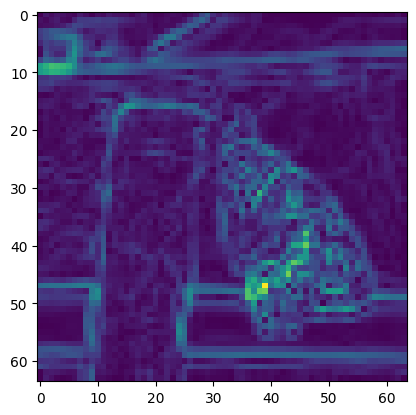

In [95]:
plt.imshow(magnitude.squeeze_())

torch.Size([4096])


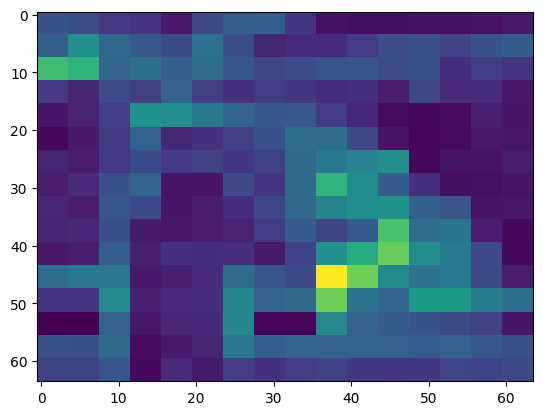

: 

In [ ]:
order_1 = 2
order_2 = 4
order_3 = 8 
order_4 = 16 
orders = [order_1, order_2, order_3, order_4]
order_level = 1  # change to 0, 1, or 2 for different levels of aggregation
inv_perm = get_hilbert_inverse(64,64)
h_magnitude = magnitude.reshape(64**2)[perm].reshape(-1, orders[order_level]**2)
h_magnitude = h_magnitude.max(dim=-1)[0][..., None].expand(-1, orders[order_level]**2).flatten() 
print(h_magnitude.shape)  # [T//(order^2), 1]
plt.imshow(h_magnitude[inv_perm].cpu().numpy().reshape(64, 64), aspect="auto")



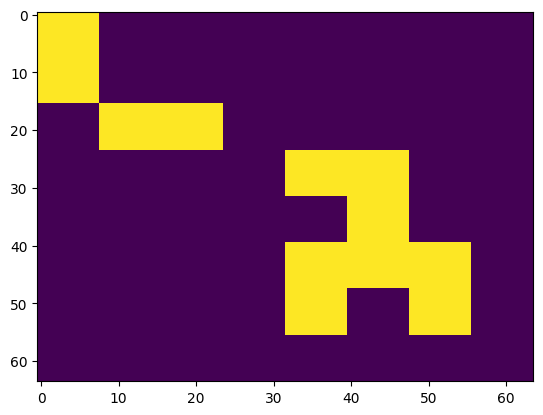

In [108]:
values = h_magnitude[inv_perm].reshape(64, 64).flatten()
p75 = np.percentile(values, 80) 

high_mask = torch.where(values > p75, 1, 0).reshape(64, 64)
plt.imshow(high_mask.reshape(64, 64), aspect="auto")

In [98]:
print(m0.reshape(1, 1024, 4096)[:, :, values > p75].shape)
print(m0.reshape(1, 1024, 4096)[:, :, values <= p75].shape)

torch.Size([1, 1024, 816])
torch.Size([1, 1024, 3280])
